# 03-Exploratory TS Analysis

In cross-sectional Machine Learning, Exploratory Data Analysis (EDA) involves looking at histograms, scatter plots, and correlation matrices to understand how feature $A$ relates to feature $B$.

In Time Series, EDA is entirely different. We are investigating how feature $A$ relates to *itself* over time. We are looking for shifting variances, hidden cycles, and structural breaks. Furthermore, we face a unique engineering nightmare: **Missing Time**.

If a row is missing in a cross-sectional dataset, you can often just delete it. If a row is missing in a Time Series, deleting it mathematically breaks the chronology of your universe.

Let's set up our Python environment to diagnose and repair temporal data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal EDA & Repair Environment Ready.")

✅ Temporal EDA & Repair Environment Ready.


# 1. Rolling Statistics (Smoothing the Noise)

Raw time series data is often incredibly noisy (e.g., daily website traffic bouncing wildly from Tuesday to Wednesday). To discover the true underlying trend, we must apply a mathematical "smoothing" filter. We do this using **Rolling Statistics** (Moving Averages).

A Simple Moving Average (SMA) calculates the mean of the data over a specific rolling window of size $k$:


$$SMA_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i}$$

By calculating both the Rolling Mean and the Rolling Standard Deviation, we can visually diagnose if our time series is mathematically stable over time.

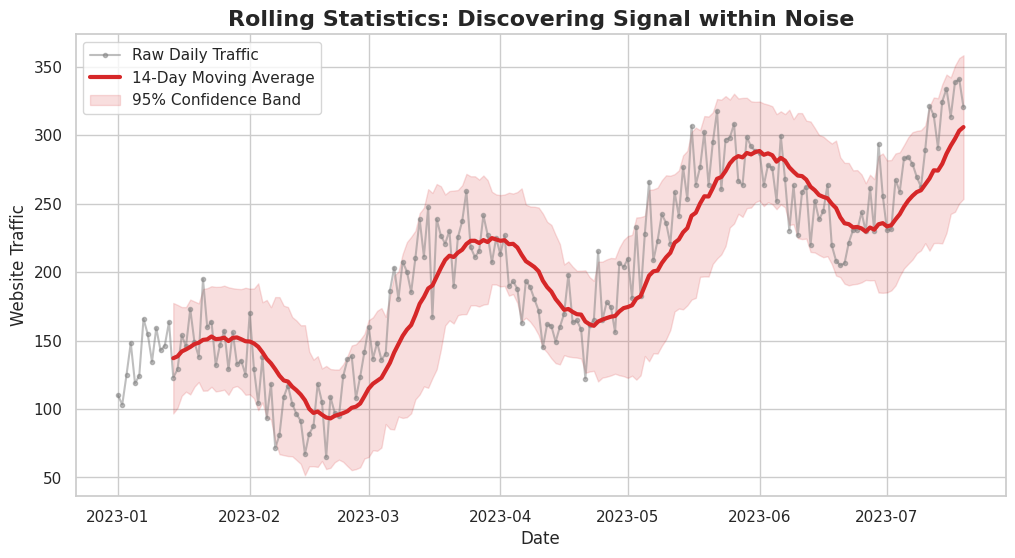

In [2]:
# 1. Simulate Daily Retail Traffic
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=200, freq='D')
traffic = np.linspace(100, 300, 200) + np.sin(np.arange(200) * 0.1) * 50 + np.random.normal(0, 20, 200)
df = pd.DataFrame({'Traffic': traffic}, index=dates)

# 2. Calculate Rolling Statistics (Window = 14 Days)
# center=False means the average at day 't' only uses data from the past 14 days (no future leakage!)
window_size = 14
df['Rolling_Mean'] = df['Traffic'].rolling(window=window_size, center=False).mean()
df['Rolling_Std'] = df['Traffic'].rolling(window=window_size, center=False).std()

# 3. Matplotlib Visualization
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Traffic'], color='#7f7f7f', alpha=0.5, marker='.', label='Raw Daily Traffic')
plt.plot(df.index, df['Rolling_Mean'], color='#d62728', linewidth=3, label=f'{window_size}-Day Moving Average')

# Fill the variance band (Mean +/- 2 Standard Deviations)
plt.fill_between(df.index, 
                 df['Rolling_Mean'] - 2 * df['Rolling_Std'], 
                 df['Rolling_Mean'] + 2 * df['Rolling_Std'], 
                 color='#d62728', alpha=0.15, label='95% Confidence Band')

plt.title("Rolling Statistics: Discovering Signal within Noise", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Website Traffic")
plt.legend(loc='upper left')
plt.show()

*(Insight: Notice how the red 14-day Moving Average smoothly tracks the underlying trend, completely ignoring the chaotic daily spikes. Also note that the red line does not start until January 15th—it needs 14 days of historical data before it can make its first calculation!)*

# 2. The Missing Time Problem (Temporal Imputation)

In enterprise datasets, sensors go offline and stores close for holidays. This results in `NaN` (Not a Number) values.

If you use a standard ML `SimpleImputer` to replace a missing value with the **Global Mean**, you will destroy the temporal signal. (If a sensor goes offline during a massive summer heatwave, replacing the missing temperature with the yearly average will erroneously inject freezing winter data into July).

Instead, we use **Temporal Interpolation**.

1. **Forward Fill (ffill)**: Propagates the last valid observation forward. Good for discrete states (e.g., assuming an interest rate stays the same until a new rate is published).
2. **Linear Interpolation**: Draws a straight mathematical line connecting the point before the gap to the point after the gap.
3. **Spline/Polynomial**: Uses calculus to fit a smooth curve through the gap, preserving momentum and seasonal curves.

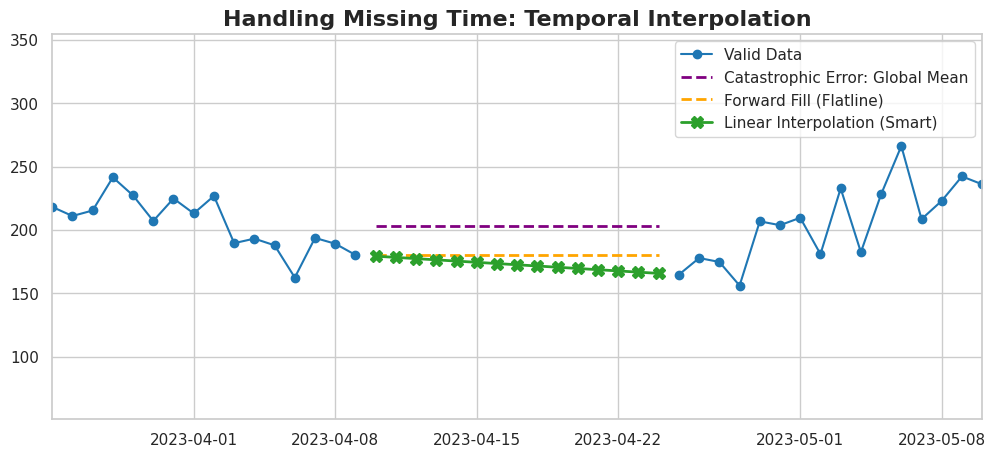

In [3]:
# 1. Simulate a gap in our data (Sensor Offline for 2 weeks in April)
df_missing = df[['Traffic']].copy()
df_missing.loc['2023-04-10':'2023-04-24', 'Traffic'] = np.nan

# 2. Apply Temporal Imputation Techniques
df_missing['Imputed_GlobalMean'] = df_missing['Traffic'].fillna(df_missing['Traffic'].mean())
df_missing['Imputed_FFill'] = df_missing['Traffic'].ffill()
df_missing['Imputed_Linear'] = df_missing['Traffic'].interpolate(method='linear')

# 3. Matplotlib Visualization of the Gap
plt.figure(figsize=(12, 5))

# Plot the valid data
plt.plot(df_missing.index, df_missing['Traffic'], color='#1f77b4', marker='o', label='Valid Data')

# Plot the Imputations during the gap
gap_mask = df_missing['Traffic'].isna()
plt.plot(df_missing[gap_mask].index, df_missing.loc[gap_mask, 'Imputed_GlobalMean'], 
         color='purple', linestyle='--', linewidth=2, label='Catastrophic Error: Global Mean')
plt.plot(df_missing[gap_mask].index, df_missing.loc[gap_mask, 'Imputed_FFill'], 
         color='orange', linestyle='--', linewidth=2, label='Forward Fill (Flatline)')
plt.plot(df_missing[gap_mask].index, df_missing.loc[gap_mask, 'Imputed_Linear'], 
         color='#2ca02c', marker='X', markersize=8, linewidth=2, label='Linear Interpolation (Smart)')

plt.title("Handling Missing Time: Temporal Interpolation", fontsize=16, fontweight='bold')
plt.xlim(pd.Timestamp('2023-03-25'), pd.Timestamp('2023-05-10')) # Zoom in on the gap
plt.legend()
plt.show()

*(Insight: Look at the purple line. Replacing missing April data with the Global Mean creates a violent, unnatural drop that will mathematically crash an algorithm like ARIMA. The green Linear Interpolation elegantly bridges the gap, allowing the algorithm to seamlessly pass through the blackout period.)*

# 3. Changing Granularity (Resampling)

Data is rarely recorded at the exact frequency your business needs. You might have timestamps down to the millisecond (`2024-05-10 14:32:01.455`), but the CFO wants a Monthly revenue forecast.

We change the frequency of a time series using **Resampling**.

* **Downsampling (Aggregating)**: Moving from a high frequency (Hourly) to a low frequency (Daily). You must provide an aggregation math function (e.g., `sum()`, `mean()`, `max()`).
* **Upsampling (Interpolating)**: Moving from a low frequency (Monthly) to a high frequency (Daily). This artificially creates `NaN` values that you must immediately interpolate using the techniques from Section 2.

In [4]:
# Downsampling Daily Traffic into Weekly Total Traffic
# 'W-MON' means we aggregate weeks starting on Monday
weekly_traffic = df['Traffic'].resample('W-MON').sum()

print("🚨 Resampling Complete.")
print(f"Original Daily Rows: {len(df)}")
print(f"New Weekly Rows:     {len(weekly_traffic)}")
print("\nBy mathematically summing the days into weeks, we have smoothed the data, eliminated day-of-week noise, and reduced our computational load for future forecasting models!")

🚨 Resampling Complete.
Original Daily Rows: 200
New Weekly Rows:     30

By mathematically summing the days into weeks, we have smoothed the data, eliminated day-of-week noise, and reduced our computational load for future forecasting models!


## Real-World Use Case or Analogy:

Think of Exploratory Time Series Analysis like **Monitoring a Patient in an ICU**:

* **Rolling Statistics (Smoothing)**: The patient's heart rate monitor jumps between 80 and 85 beats per minute every second. The doctor doesn't care about the 1-second noise. They look at the 5-minute Rolling Average on the screen to see if the patient's baseline stress level is rising over the hour.
* **Temporal Interpolation (Missing Time)**: The nurse accidentally unplugs the sensor for 10 seconds. You do not record that the patient's heart rate was 0 BPM (deleting the data) or 72 BPM (the lifetime global average). You mathematically interpolate the gap, assuming the heart rate smoothly transitioned from where it was unplugged to where it was plugged back in.
* **Resampling (Granularity)**: The raw sensor records 100 data points per second. But the final medical chart handed to the surgeon only shows the `max()` heart rate recorded for each hour.

---